# EcoAudit Dataset Analysis
Analysis of the waste classification dataset containing 14 categories of waste images.

## 1. Setup & Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import defaultdict

sns.set_theme(style='whitegrid')
DATASET_DIR = Path('Dataset')
CLASSES = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
print(f'Classes ({len(CLASSES)}): {CLASSES}')

Classes (14): ['Battery', 'Biological', 'Cable', 'Can', 'Cardboard', 'Clothes', 'E-waste', 'Glass', 'Medical Waste', 'Metal', 'Paper', 'Plastic', 'Shoes', 'Trash']


## 2. Class Distribution

In [2]:
# Count images per class
class_counts = {}
for cls in CLASSES:
    images = list((DATASET_DIR / cls).glob('*.jpg')) + \
             list((DATASET_DIR / cls).glob('*.jpeg')) + \
             list((DATASET_DIR / cls).glob('*.png'))
    class_counts[cls] = len(images)

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False).reset_index(drop=True)
total = df_counts['Count'].sum()
df_counts['Percentage'] = (df_counts['Count'] / total * 100).round(2)
print(f'Total images: {total}')
print(df_counts.to_string(index=False))

Total images: 13587
        Class  Count  Percentage
        Glass   1921       14.14
      Clothes   1892       13.93
      Plastic   1851       13.62
        Shoes   1449       10.66
    Cardboard   1411       10.38
        Paper   1336        9.83
        Metal   1143        8.41
      Battery    756        5.56
   Biological    699        5.14
        Trash    453        3.33
      E-waste    334        2.46
        Cable    162        1.19
          Can    100        0.74
Medical Waste     80        0.59


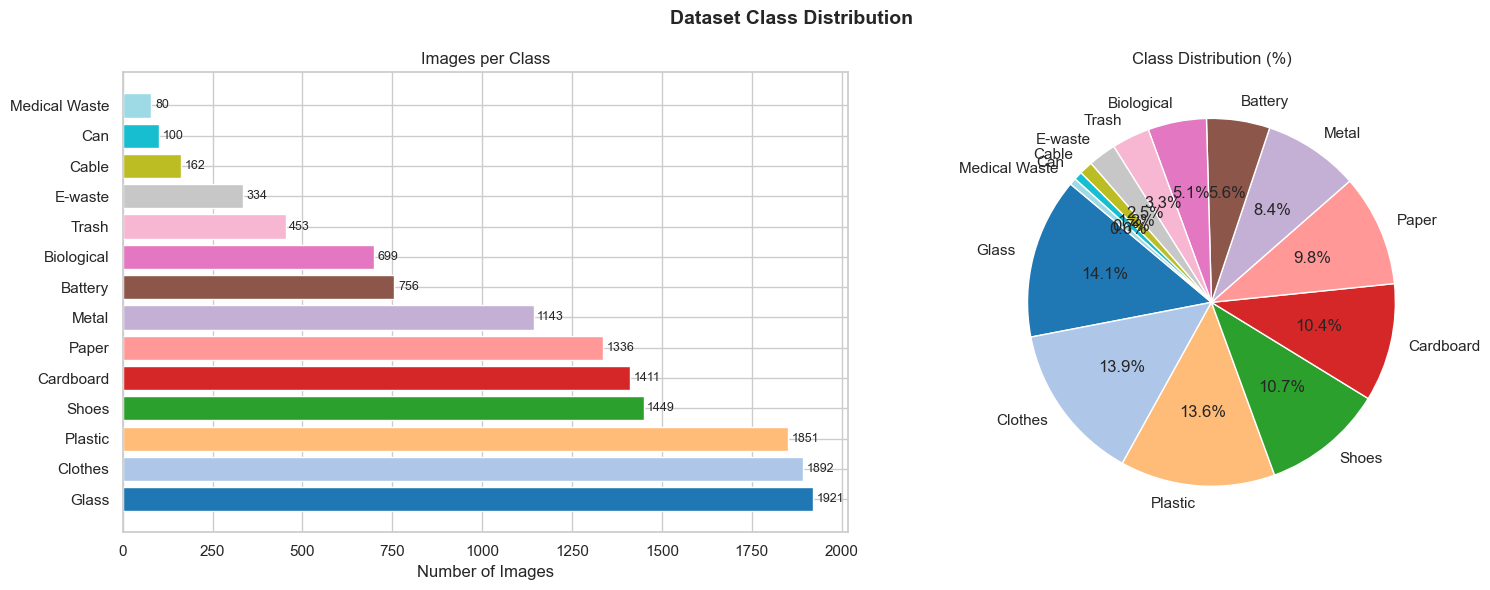

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = plt.cm.tab20(np.linspace(0, 1, len(df_counts)))
bars = axes[0].barh(df_counts['Class'], df_counts['Count'], color=colors)
axes[0].set_xlabel('Number of Images')
axes[0].set_title('Images per Class')
for bar, count in zip(bars, df_counts['Count']):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 str(count), va='center', fontsize=9)

# Pie chart
axes[1].pie(df_counts['Count'], labels=df_counts['Class'], autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Dataset Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Class Imbalance Analysis

In [4]:
max_count = df_counts['Count'].max()
min_count = df_counts['Count'].min()
mean_count = df_counts['Count'].mean()
imbalance_ratio = max_count / min_count

print(f'Max class  : {df_counts.iloc[df_counts["Count"].argmax()]["Class"]} ({max_count})')
print(f'Min class  : {df_counts.iloc[df_counts["Count"].argmin()]["Class"]} ({min_count})')
print(f'Mean count : {mean_count:.1f}')
print(f'Std dev    : {df_counts["Count"].std():.1f}')
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x')

# Flag underrepresented classes (< 50% of mean)
threshold = mean_count * 0.5
underrepresented = df_counts[df_counts['Count'] < threshold]
print(f'\nUnderrepresented classes (< {threshold:.0f} images):')
print(underrepresented[['Class', 'Count']].to_string(index=False))

Max class  : Glass (1921)
Min class  : Medical Waste (80)
Mean count : 970.5
Std dev    : 685.6
Imbalance ratio (max/min): 24.0x

Underrepresented classes (< 485 images):
        Class  Count
        Trash    453
      E-waste    334
        Cable    162
          Can    100
Medical Waste     80


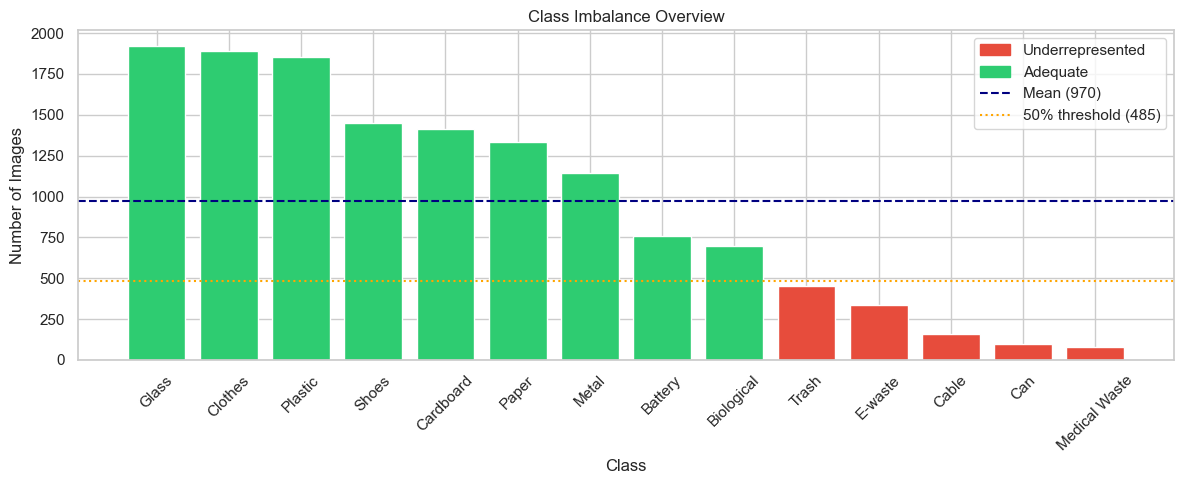

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#e74c3c' if c < threshold else '#2ecc71' for c in df_counts['Count']]
ax.bar(df_counts['Class'], df_counts['Count'], color=bar_colors)
ax.axhline(mean_count, color='navy', linestyle='--', label=f'Mean ({mean_count:.0f})')
ax.axhline(threshold, color='orange', linestyle=':', label=f'50% threshold ({threshold:.0f})')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_title('Class Imbalance Overview')
ax.tick_params(axis='x', rotation=45)
red_patch = mpatches.Patch(color='#e74c3c', label='Underrepresented')
green_patch = mpatches.Patch(color='#2ecc71', label='Adequate')
ax.legend(handles=[red_patch, green_patch] + ax.get_legend_handles_labels()[0])
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Image Properties Analysis

In [6]:
# Sample up to 50 images per class for property analysis
SAMPLE_SIZE = 50
records = []

for cls in CLASSES:
    paths = list((DATASET_DIR / cls).glob('*.jpg')) + \
            list((DATASET_DIR / cls).glob('*.jpeg')) + \
            list((DATASET_DIR / cls).glob('*.png'))
    sampled = paths[:SAMPLE_SIZE]
    for p in sampled:
        try:
            img = Image.open(p)
            w, h = img.size
            file_size_kb = p.stat().st_size / 1024
            records.append({
                'class': cls,
                'width': w,
                'height': h,
                'aspect_ratio': round(w / h, 3),
                'mode': img.mode,
                'file_size_kb': round(file_size_kb, 2)
            })
        except Exception as e:
            print(f'Error reading {p}: {e}')

df_props = pd.DataFrame(records)
print(f'Sampled {len(df_props)} images across {df_props["class"].nunique()} classes')
print('\nImage mode distribution:')
print(df_props['mode'].value_counts())

Sampled 700 images across 14 classes

Image mode distribution:
mode
RGB    700
Name: count, dtype: int64


In [7]:
print('Image dimension statistics:')
print(df_props[['width', 'height', 'aspect_ratio', 'file_size_kb']].describe().round(2))

Image dimension statistics:
         width   height  aspect_ratio  file_size_kb
count   700.00   700.00        700.00        700.00
mean    529.58   502.29          1.12         55.37
std     283.64   265.51          0.28        141.53
min     158.00   126.00          0.38          1.75
25%     300.75   248.50          1.00         10.88
50%     640.00   640.00          1.00         36.36
75%     640.00   640.00          1.33         64.22
max    4032.00  3024.00          3.18       3052.45


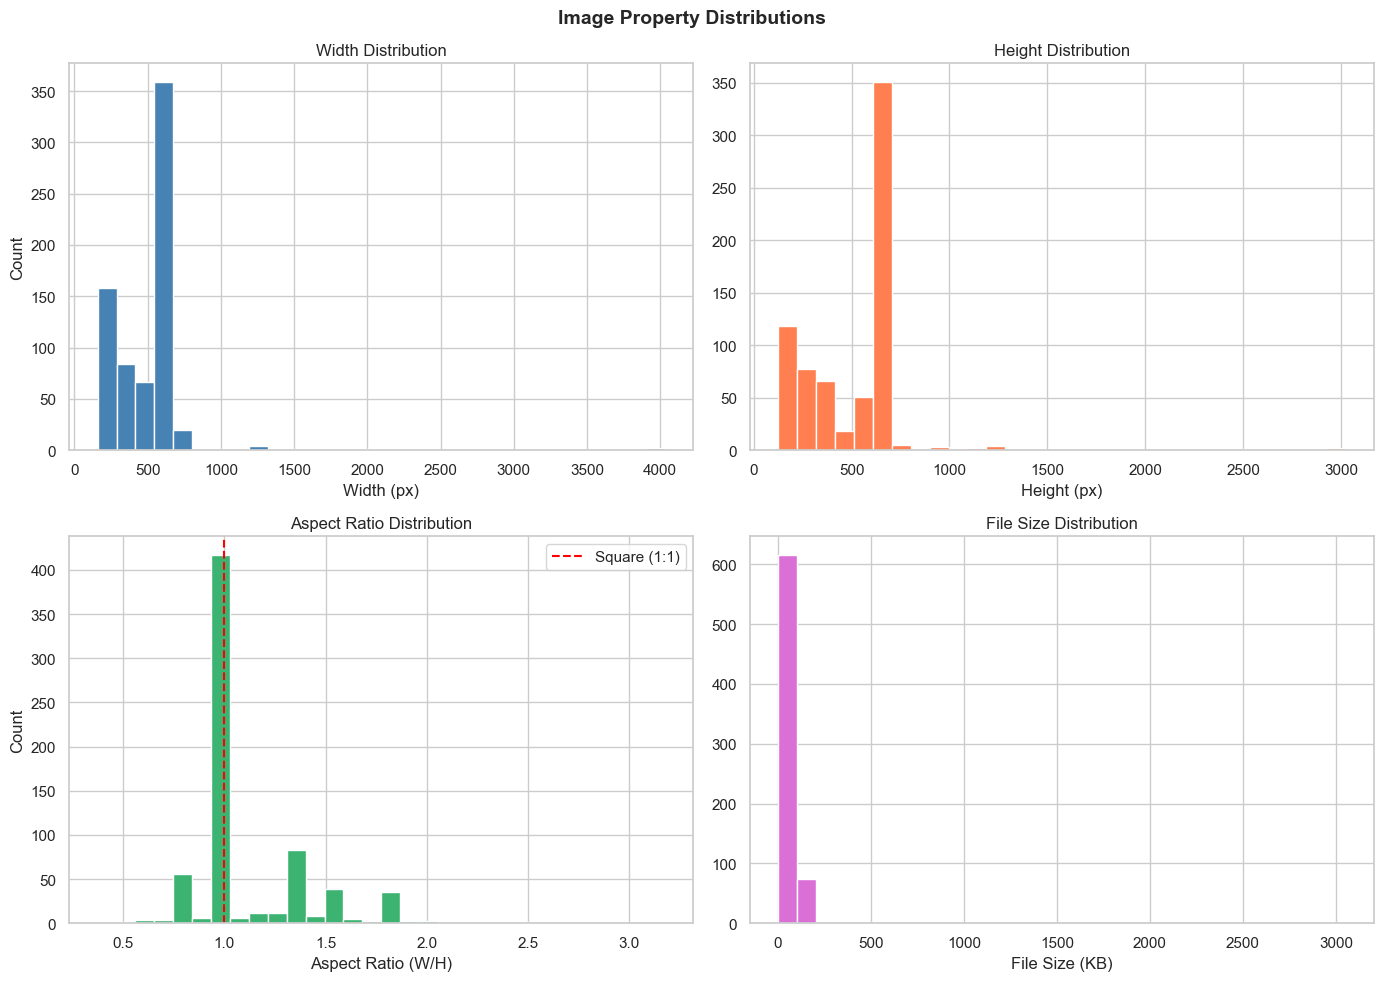

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width distribution
axes[0, 0].hist(df_props['width'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Width Distribution')
axes[0, 0].set_xlabel('Width (px)')
axes[0, 0].set_ylabel('Count')

# Height distribution
axes[0, 1].hist(df_props['height'], bins=30, color='coral', edgecolor='white')
axes[0, 1].set_title('Height Distribution')
axes[0, 1].set_xlabel('Height (px)')

# Aspect ratio distribution
axes[1, 0].hist(df_props['aspect_ratio'], bins=30, color='mediumseagreen', edgecolor='white')
axes[1, 0].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
axes[1, 0].set_title('Aspect Ratio Distribution')
axes[1, 0].set_xlabel('Aspect Ratio (W/H)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# File size distribution
axes[1, 1].hist(df_props['file_size_kb'], bins=30, color='orchid', edgecolor='white')
axes[1, 1].set_title('File Size Distribution')
axes[1, 1].set_xlabel('File Size (KB)')

plt.suptitle('Image Property Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('image_properties.png', dpi=150, bbox_inches='tight')
plt.show()

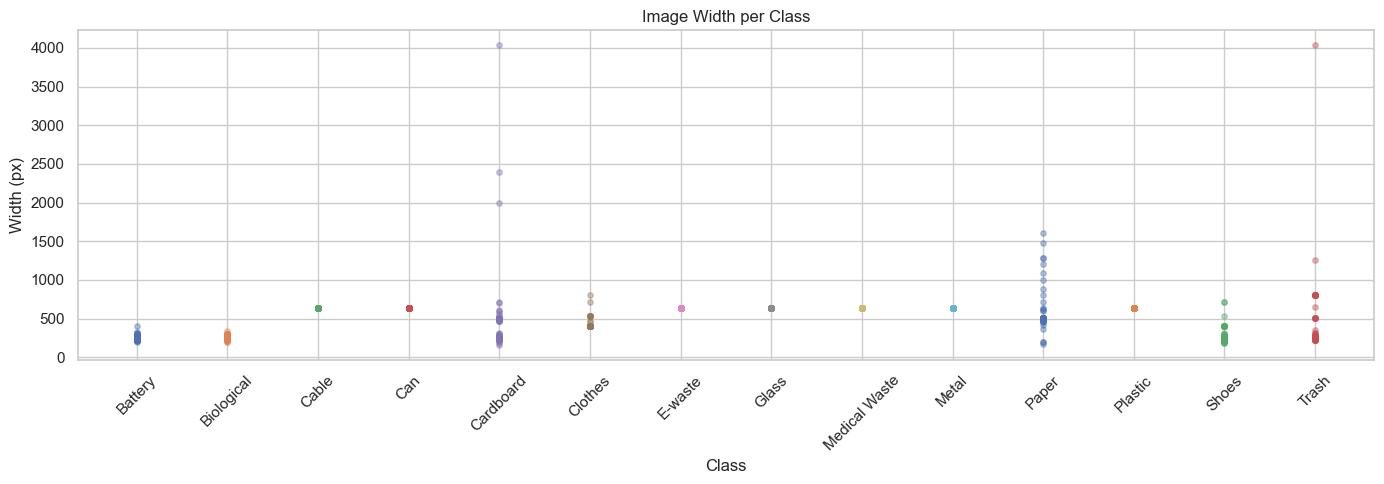

In [9]:
# Width scatter per class
fig, ax = plt.subplots(figsize=(14, 5))
for i, cls in enumerate(CLASSES):
    subset = df_props[df_props['class'] == cls]
    ax.scatter([cls] * len(subset), subset['width'], alpha=0.4, s=15)
ax.set_xlabel('Class')
ax.set_ylabel('Width (px)')
ax.set_title('Image Width per Class')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Sample Image Visualization

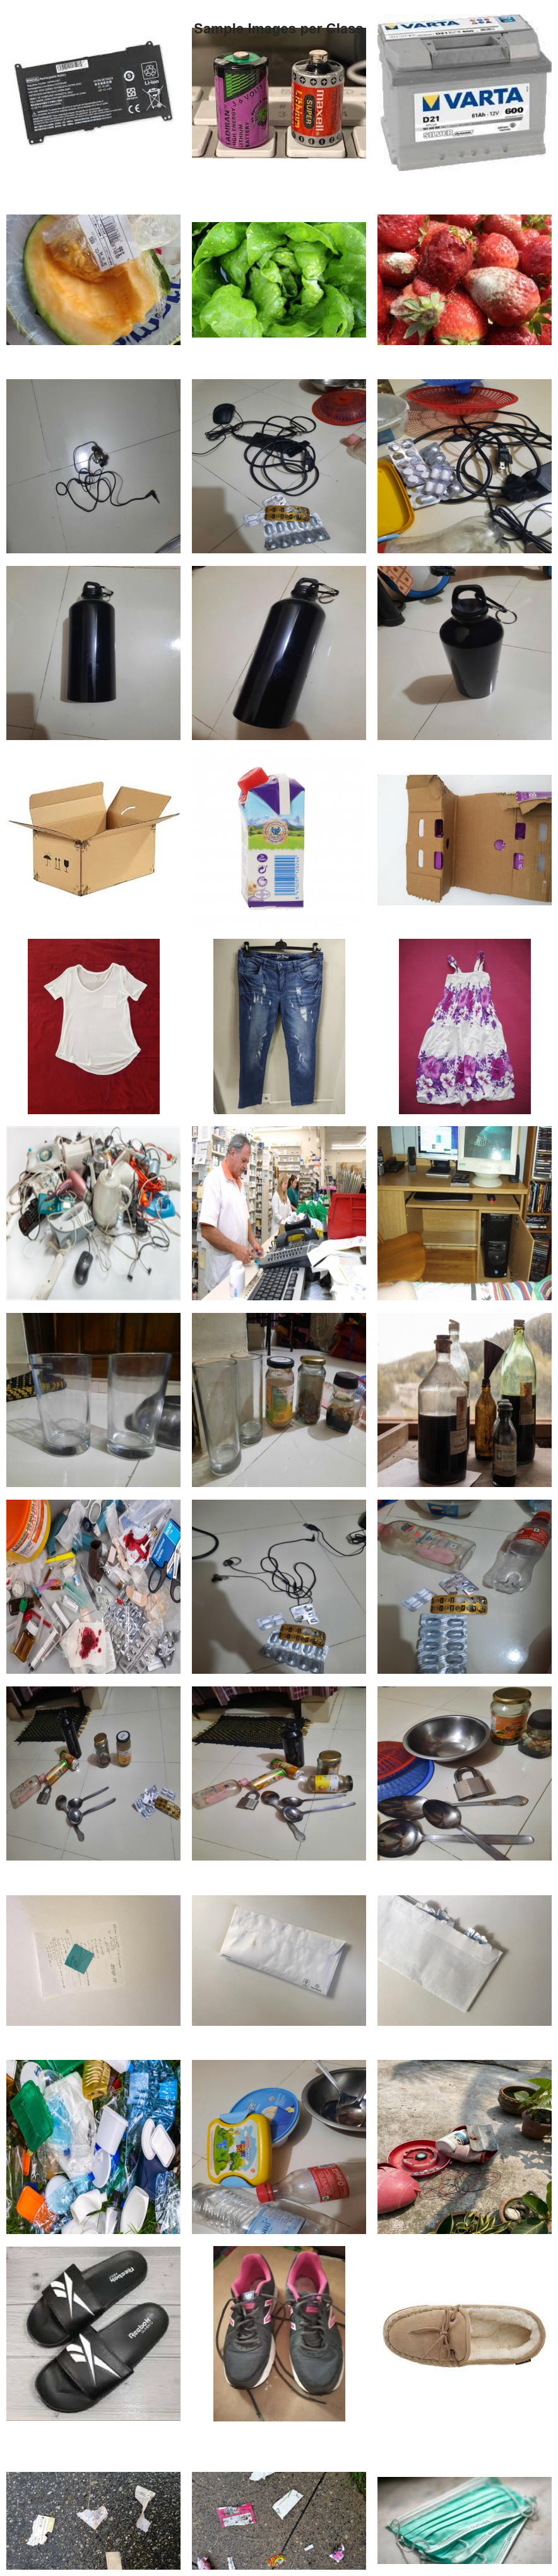

In [10]:
# Show 3 sample images per class
N_SAMPLES = 3
n_classes = len(CLASSES)
fig, axes = plt.subplots(n_classes, N_SAMPLES, figsize=(N_SAMPLES * 3, n_classes * 3))

for row, cls in enumerate(CLASSES):
    paths = list((DATASET_DIR / cls).glob('*.jpg'))[:N_SAMPLES]
    for col in range(N_SAMPLES):
        ax = axes[row, col]
        if col < len(paths):
            img = Image.open(paths[col]).convert('RGB')
            ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0,
                          labelpad=60, ha='right', va='center')

plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Color Analysis (Mean RGB per Class)

In [11]:
# Compute mean RGB per class (resize to 64x64 for speed)
THUMB = (64, 64)
SAMPLE_PER_CLASS = 30
color_stats = {}

for cls in CLASSES:
    paths = list((DATASET_DIR / cls).glob('*.jpg'))[:SAMPLE_PER_CLASS]
    pixels = []
    for p in paths:
        try:
            img = Image.open(p).convert('RGB').resize(THUMB)
            pixels.append(np.array(img).reshape(-1, 3))
        except:
            pass
    if pixels:
        all_px = np.vstack(pixels)
        color_stats[cls] = {
            'mean_r': all_px[:, 0].mean(),
            'mean_g': all_px[:, 1].mean(),
            'mean_b': all_px[:, 2].mean(),
            'std_r': all_px[:, 0].std(),
            'std_g': all_px[:, 1].std(),
            'std_b': all_px[:, 2].std(),
            'brightness': all_px.mean()
        }

df_color = pd.DataFrame(color_stats).T.round(2)
print(df_color)

               mean_r  mean_g  mean_b  std_r  std_g  std_b  brightness
Battery        184.36  182.46  180.36  82.88  83.38  85.16      182.39
Biological     158.98  132.22  101.25  69.86  71.24  75.60      130.82
Cable          151.69  135.66  126.10  51.42  52.61  52.83      137.81
Can            134.16  129.23  122.39  54.64  55.59  57.10      128.60
Cardboard      196.84  184.70  165.73  58.48  63.69  78.27      182.42
Clothes        144.90  114.26  113.26  62.54  61.87  58.45      124.14
E-waste        122.65  114.02  105.37  72.99  73.46  75.55      114.01
Glass          106.73   94.53   81.77  65.37  62.37  62.92       94.34
Medical Waste  140.77  129.87  123.78  50.03  52.42  51.39      131.47
Metal          132.72  125.53  122.38  50.29  53.75  56.08      126.88
Paper          161.91  155.79  146.66  59.11  58.41  59.48      154.79
Plastic        147.60  128.31  116.45  56.87  55.32  55.47      130.79
Shoes          159.42  150.84  142.26  77.40  78.51  80.74      150.84
Trash 

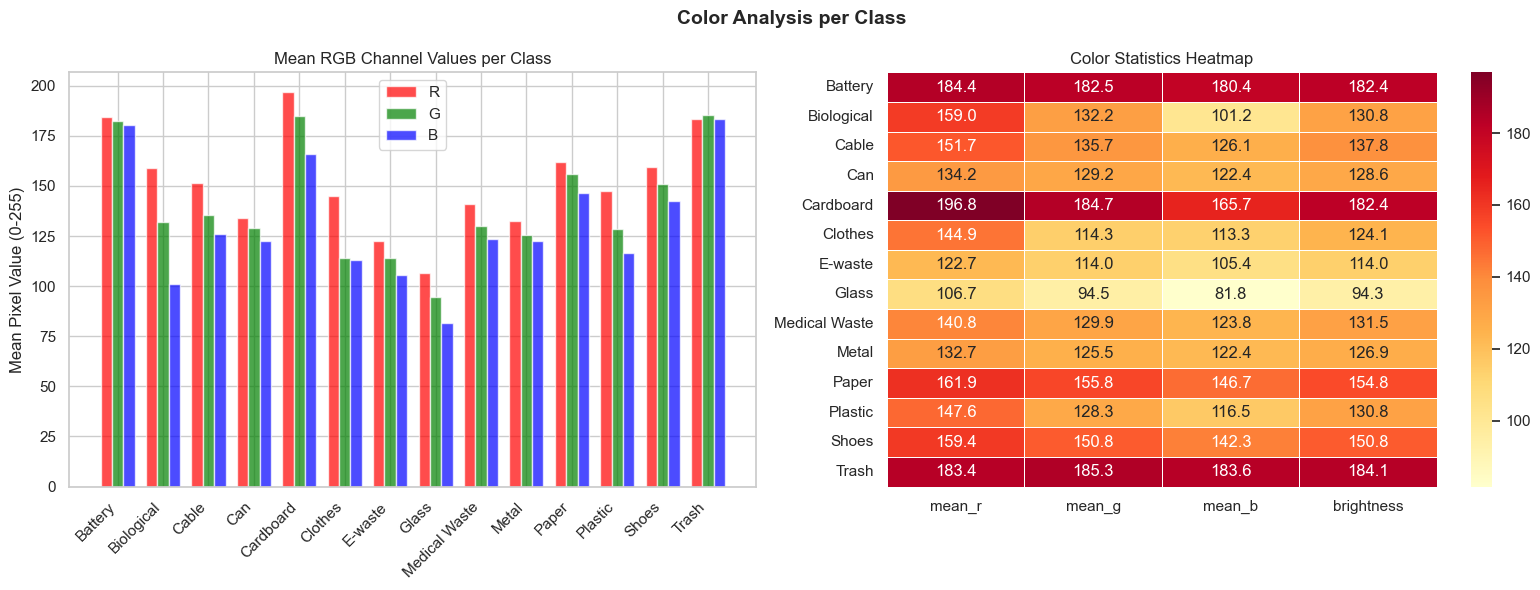

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean RGB grouped bar chart
x = np.arange(len(df_color))
width = 0.25
axes[0].bar(x - width, df_color['mean_r'], width, label='R', color='red', alpha=0.7)
axes[0].bar(x,         df_color['mean_g'], width, label='G', color='green', alpha=0.7)
axes[0].bar(x + width, df_color['mean_b'], width, label='B', color='blue', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_color.index, rotation=45, ha='right')
axes[0].set_ylabel('Mean Pixel Value (0-255)')
axes[0].set_title('Mean RGB Channel Values per Class')
axes[0].legend()

# Brightness heatmap
brightness_df = df_color[['mean_r', 'mean_g', 'mean_b', 'brightness']]
sns.heatmap(brightness_df, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Color Statistics Heatmap')

plt.suptitle('Color Analysis per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('color_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pixel Intensity Histogram (Overall)

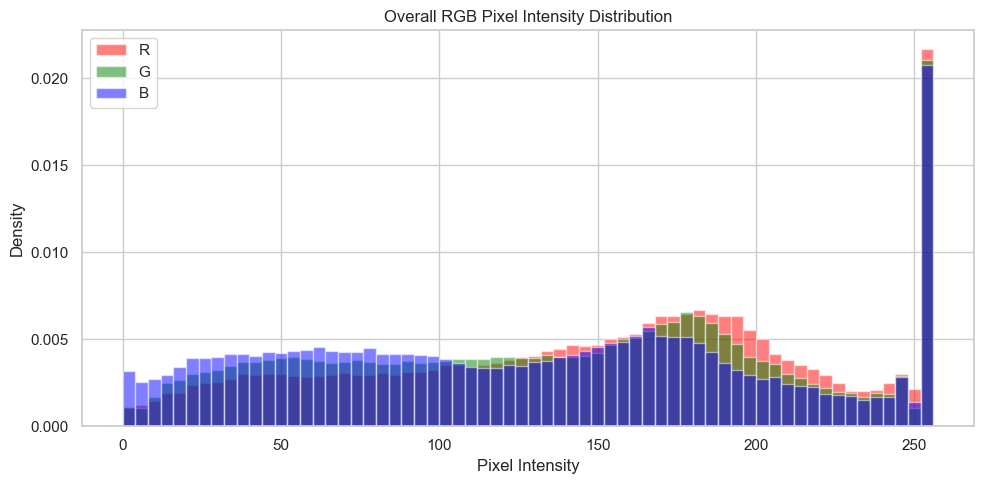

In [13]:
# Sample a few images from each class and compute overall pixel histogram
all_r, all_g, all_b = [], [], []
SAMPLE_HIST = 10

for cls in CLASSES:
    paths = list((DATASET_DIR / cls).glob('*.jpg'))[:SAMPLE_HIST]
    for p in paths:
        try:
            img = np.array(Image.open(p).convert('RGB').resize((64, 64)))
            all_r.extend(img[:, :, 0].flatten())
            all_g.extend(img[:, :, 1].flatten())
            all_b.extend(img[:, :, 2].flatten())
        except:
            pass

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(0, 257, 4)
ax.hist(all_r, bins=bins, color='red',   alpha=0.5, label='R', density=True)
ax.hist(all_g, bins=bins, color='green', alpha=0.5, label='G', density=True)
ax.hist(all_b, bins=bins, color='blue',  alpha=0.5, label='B', density=True)
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Density')
ax.set_title('Overall RGB Pixel Intensity Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('pixel_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Train / Validation / Test Split Recommendation

In [14]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

split_data = []
for _, row in df_counts.iterrows():
    n = row['Count']
    train = int(n * TRAIN_RATIO)
    val   = int(n * VAL_RATIO)
    test  = n - train - val
    split_data.append({'Class': row['Class'], 'Total': n,
                       'Train': train, 'Val': val, 'Test': test})

df_split = pd.DataFrame(split_data)
df_split.loc['Total'] = df_split.sum(numeric_only=True)
df_split.loc['Total', 'Class'] = 'TOTAL'
print(df_split.to_string(index=False))

        Class   Total  Train    Val   Test
        Glass  1921.0 1344.0  288.0  289.0
      Clothes  1892.0 1324.0  283.0  285.0
      Plastic  1851.0 1295.0  277.0  279.0
        Shoes  1449.0 1014.0  217.0  218.0
    Cardboard  1411.0  987.0  211.0  213.0
        Paper  1336.0  935.0  200.0  201.0
        Metal  1143.0  800.0  171.0  172.0
      Battery   756.0  529.0  113.0  114.0
   Biological   699.0  489.0  104.0  106.0
        Trash   453.0  317.0   67.0   69.0
      E-waste   334.0  233.0   50.0   51.0
        Cable   162.0  113.0   24.0   25.0
          Can   100.0   70.0   15.0   15.0
Medical Waste    80.0   56.0   12.0   12.0
        TOTAL 13587.0 9506.0 2032.0 2049.0


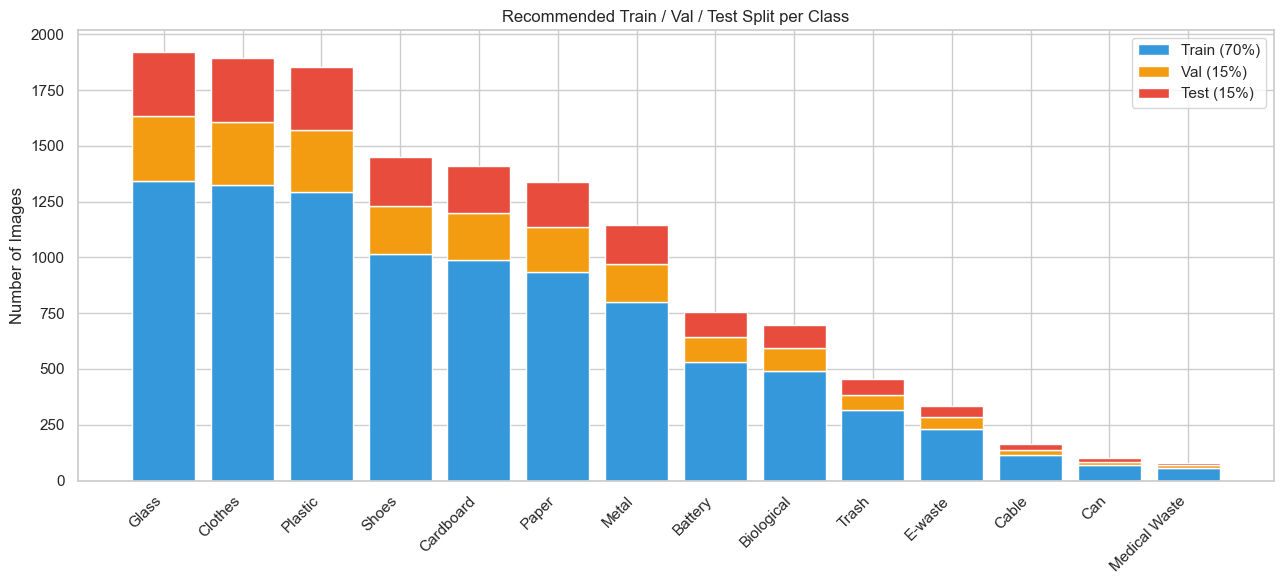

In [15]:
df_plot = df_split[df_split['Class'] != 'TOTAL']
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_plot))
ax.bar(x, df_plot['Train'], label='Train (70%)', color='#3498db')
ax.bar(x, df_plot['Val'],   bottom=df_plot['Train'], label='Val (15%)', color='#f39c12')
ax.bar(x, df_plot['Test'],  bottom=df_plot['Train']+df_plot['Val'], label='Test (15%)', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Class'], rotation=45, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Recommended Train / Val / Test Split per Class')
ax.legend()
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Report

In [16]:
print('=' * 55)
print('          ECOAUDIT DATASET SUMMARY REPORT')
print('=' * 55)
print(f'  Total classes          : {len(CLASSES)}')
print(f'  Total images           : {total}')
print(f'  Largest class          : {df_counts.iloc[0]["Class"]} ({df_counts.iloc[0]["Count"]})')
print(f'  Smallest class         : {df_counts.iloc[-1]["Class"]} ({df_counts.iloc[-1]["Count"]})')
print(f'  Imbalance ratio        : {imbalance_ratio:.1f}x')
print(f'  Avg images/class       : {mean_count:.0f}')
print(f'  Unique image modes     : {df_props["mode"].unique()}')
print(f'  Median width           : {df_props["width"].median():.0f} px')
print(f'  Median height          : {df_props["height"].median():.0f} px')
print(f'  Median file size       : {df_props["file_size_kb"].median():.1f} KB')
print('\nRecommendations:')
if imbalance_ratio > 5:
    print('  [!] High class imbalance detected.')
    print('      Consider oversampling minority classes or using')
    print('      weighted loss functions during training.')
print('  [i] Apply data augmentation (flip, rotate, crop, color jitter)')
print('      to improve model generalization.')
print('  [i] Resize all images to a uniform size before training')
print('      (e.g., 224x224 for pretrained CNN backbones).')
print('=' * 55)

          ECOAUDIT DATASET SUMMARY REPORT
  Total classes          : 14
  Total images           : 13587
  Largest class          : Glass (1921)
  Smallest class         : Medical Waste (80)
  Imbalance ratio        : 24.0x
  Avg images/class       : 970
  Unique image modes     : ['RGB']
  Median width           : 640 px
  Median height          : 640 px
  Median file size       : 36.4 KB

Recommendations:
  [!] High class imbalance detected.
      Consider oversampling minority classes or using
      weighted loss functions during training.
  [i] Apply data augmentation (flip, rotate, crop, color jitter)
      to improve model generalization.
  [i] Resize all images to a uniform size before training
      (e.g., 224x224 for pretrained CNN backbones).


Tier Counts:
                    Tier  Count
Tier 4: Clean Recyclable   7762
   Tier 3: Non-hazardous   3794
Tier 1: Immediate Hazard   1535
Tier 2: Special Handling    496


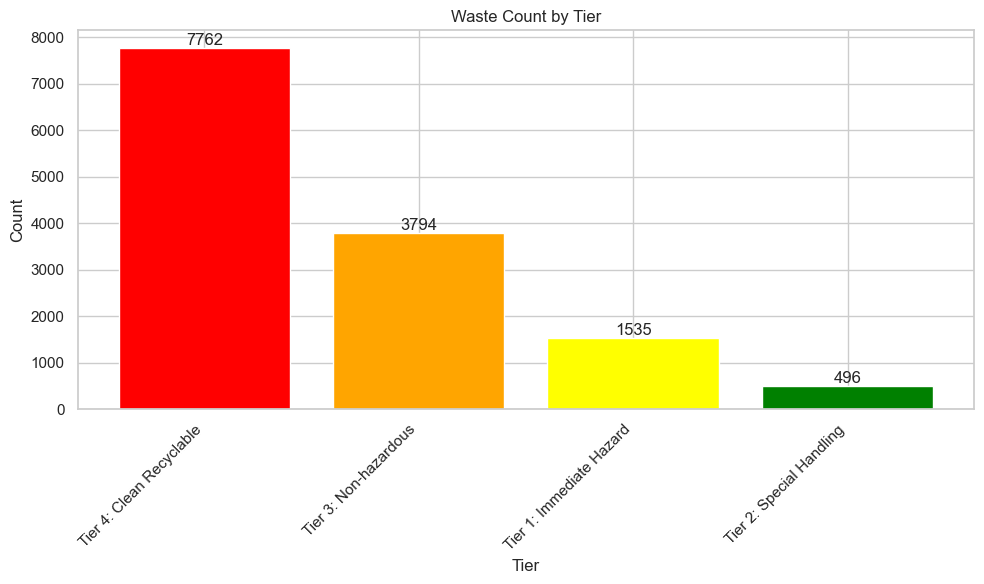

In [18]:
# Tier Analysis
tier_mapping = {
    'Battery': 'Tier 1: Immediate Hazard',
    'Biological': 'Tier 1: Immediate Hazard',
    'Medical Waste': 'Tier 1: Immediate Hazard',
    'E-waste': 'Tier 2: Special Handling',
    'Cable': 'Tier 2: Special Handling',
    'Clothes': 'Tier 3: Non-hazardous',
    'Shoes': 'Tier 3: Non-hazardous',
    'Trash': 'Tier 3: Non-hazardous',
    'Can': 'Tier 4: Clean Recyclable',
    'Cardboard': 'Tier 4: Clean Recyclable',
    'Glass': 'Tier 4: Clean Recyclable',
    'Metal': 'Tier 4: Clean Recyclable',
    'Paper': 'Tier 4: Clean Recyclable',
    'Plastic': 'Tier 4: Clean Recyclable',
}

df_counts['Tier'] = df_counts['Class'].map(tier_mapping)
tier_counts = df_counts.groupby('Tier')['Count'].sum().reset_index()
tier_counts = tier_counts.sort_values('Count', ascending=False)

print("Tier Counts:")
print(tier_counts.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(tier_counts['Tier'], tier_counts['Count'], color=['red', 'orange', 'yellow', 'green'])
ax.set_title('Waste Count by Tier')
ax.set_xlabel('Tier')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()